In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt

In [3]:
import crosscoders as xc
import torch


------------------------- CONSTANTS -------------------------
GlobalsConfig(
    PROJECT_ROOT_DIR = '/home/ec2-user/crosscoders',
    CONFIG_FILEPATH = '/home/ec2-user/crosscoders/src/scripts/configs/train.tiny-stories-33M.yml',
    DATA_DIR = '/home/ec2-user/crosscoders/data',
    EXPERIMENT = ExperimentConfig(
        BATCH_SIZE = 25000,
        MAX_RECORDS = None,
        MAX_BATCHES = 400,
        MAX_TOKENS = 10000000,
        NUM_GPUS = 1,
        NUM_TRAINERS = 1,
        HARDWARE = HardwareConfig(
            dtype = torch.float32,
            device = 'cuda',
        ),
    ),
)
-------------------------------------------------------------



In [4]:
# from crosscoders.autoencoders.acausal.model import JumpReLUFunction


# JumpReLUFunction()

In [ ]:
from crosscoders import CONSTANTS
from crosscoders.autoencoders.runner import Runner, RunnerConfig
from crosscoders.utils import from_dict, get_config

runner_cfg = from_dict(
    RunnerConfig,
    get_config(CONSTANTS.CONFIG_FILEPATH).get('RUNNER', {})
)

runner = Runner(runner_cfg)

In [8]:
runner.scheduler['lr'].get_last_lr()[0]

0.0004

In [5]:

from crosscoders.constants import CONSTANTS
from crosscoders.dataclasses.configs.runner import RunnerConfig
from crosscoders.utils import from_dict, get_config


runner_cfg = from_dict(
    RunnerConfig,
    get_config(CONSTANTS.CONFIG_FILEPATH).get('RUNNER', {})
)
runner_cfg

TypeError: RunnerConfig.__init__() missing 1 required positional argument: 'MODEL'

In [ ]:
from crosscoders.autoencoders.acausal.runner import AcausalAutoencoderRunner


runner = AcausalAutoencoderRunner(runner_cfg)

NameError: name 'runner_cfg' is not defined

In [5]:
CONSTANTS.EXPERIMENT.MAX_TOKENS = 10000

NameError: name 'CONSTANTS' is not defined

In [6]:
from crosscoders.data.dataset import TinyStoriesRayDataset


train_ds = TinyStoriesRayDataset(s3_prefix='tiny-stories-33M/100M-shuffled/').load('activations')
train_ds

2025-02-24 20:26:31,156	WARNING file_meta_provider.py:211 -- Skipping expansion of 10000 path(s). If your paths contain directories or if file size collection is required, try rerunning this read with `meta_provider=DefaultFileMetadataProvider()`.
2025-02-24 20:26:31,185	INFO worker.py:1654 -- Connecting to existing Ray cluster at address: 10.0.1.126:6379...
2025-02-24 20:26:31,198	INFO worker.py:1832 -- Connected to Ray cluster. View the dashboard at http://127.0.0.1:8265 
2025-02-24 20:26:31,297	INFO streaming_executor.py:108 -- Starting execution of Dataset. Full logs are in /tmp/ray/session_2025-02-24_20-04-50_057664_4441/logs/ray-data
2025-02-24 20:26:31,298	INFO streaming_executor.py:109 -- Execution plan of Dataset: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadParquetBulk]


Running 0: 0.00 row [00:00, ? row/s]

- ReadParquetBulk 1: 0.00 row [00:00, ? row/s]

limit=1000000
+- Dataset(
      num_rows=?,
      schema={
         tokens: int32,
         tiny-stories-33M.ln2.normalized: list<element: float>,
         tiny-stories-33M.mlp_out: list<element: float>,
         tiny-stories-33M.resid_post: list<element: float>
      }
   )

In [7]:
batch = train_ds.take_batch(5)
batch

2025-02-24 20:26:34,033	INFO streaming_executor.py:108 -- Starting execution of Dataset. Full logs are in /tmp/ray/session_2025-02-24_20-04-50_057664_4441/logs/ray-data
2025-02-24 20:26:34,034	INFO streaming_executor.py:109 -- Execution plan of Dataset: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadParquetBulk] -> LimitOperator[limit=1000000] -> LimitOperator[limit=5]


Running 0: 0.00 row [00:00, ? row/s]

- ReadParquetBulk 1: 0.00 row [00:00, ? row/s]

- limit=1000000 2: 0.00 row [00:00, ? row/s]

- limit=5 3: 0.00 row [00:00, ? row/s]

{'tokens': array([ 379,  981,  640, 2921,  257], dtype=int32),
 'tiny-stories-33M.ln2.normalized': array([array([ 0.5590018 ,  0.29083034,  0.8337091 , ...,  1.042036  ,
               -0.19113497, -0.97945786], dtype=float32)               ,
        array([ 0.6134508 ,  0.9596209 ,  3.4290872 , ...,  0.10110541,
                0.31501764, -0.02311083], dtype=float32)               ,
        array([-0.7729035 , -0.05786578,  0.07149718, ..., -0.2846172 ,
               -0.57631856, -0.95639527], dtype=float32)               ,
        array([ 0.00600636,  0.23536484, -0.71005404, ..., -0.23220399,
               -0.51727086,  0.39274806], dtype=float32)               ,
        array([ 0.2479564 ,  0.49585095,  0.9405475 , ...,  0.35670397,
               -0.86351246,  0.11398685], dtype=float32)               ],
       dtype=object),
 'tiny-stories-33M.mlp_out': array([array([ 0.09406237, -0.05841621,  0.0671766 , ..., -0.5535121 ,
                0.6661482 , -0.06981853], dtype=float3

In [12]:
batch['tiny-stories-33M.ln2.normalized'].shape

(5, 4, 768)

In [8]:
from transformer_lens import HookedTransformer

model = HookedTransformer.from_pretrained('tiny-stories-33M')

Loaded pretrained model tiny-stories-33M into HookedTransformer


In [10]:
model.to_string(batch['tokens'])

' at while time gave a'

In [36]:
train_ds.write_parquet(
            '/home/ec2-user/crosscoders/data/input/roneneldan/TinyStories/train',
            compression='LZ4',
            concurrency=6,
            ray_remote_args={
                'num_cpus': 1
            },
        )

2025-02-17 21:21:41,055	INFO streaming_executor.py:108 -- Starting execution of Dataset. Full logs are in /tmp/ray/session_2025-02-17_18-26-12_887184_15383/logs/ray-data
2025-02-17 21:21:41,055	INFO streaming_executor.py:109 -- Execution plan of Dataset: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadParquet] -> LimitOperator[limit=1000000] -> TaskPoolMapOperator[Write]


Running 0: 0.00 row [00:00, ? row/s]

- ReadParquet->SplitBlocks(2) 1: 0.00 row [00:00, ? row/s]

- limit=1000000 2: 0.00 row [00:00, ? row/s]

- Write 3: 0.00 row [00:00, ? row/s]

2025-02-17 21:27:58,315	INFO dataset.py:3969 -- Data sink Parquet finished. 1000000 rows and 34.3GB data written.


In [9]:
train_dl = train_ds.iter_torch_batches(
    batch_size=CONSTANTS.EXPERIMENT.BATCH_SIZE,
    # local_shuffle_buffer_size=16
    device='cuda'
)

In [11]:
for batch_idx, batch in enumerate(train_dl):

    # loss = runner.training_step(batch)

    # print(loss)

    break

2025-02-14 18:56:12,746	INFO streaming_executor.py:108 -- Starting execution of Dataset. Full logs are in /tmp/ray/session_2025-02-14_18-52-24_879061_2856/logs/ray-data
2025-02-14 18:56:12,747	INFO streaming_executor.py:109 -- Execution plan of Dataset: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadParquet] -> LimitOperator[limit=1000]


Running 0: 0.00 row [00:00, ? row/s]

- ReadParquet->SplitBlocks(2) 1: 0.00 row [00:00, ? row/s]

- limit=1000 2: 0.00 row [00:00, ? row/s]

In [12]:
x = batch['resid_post']

x_hat = runner.model(x)

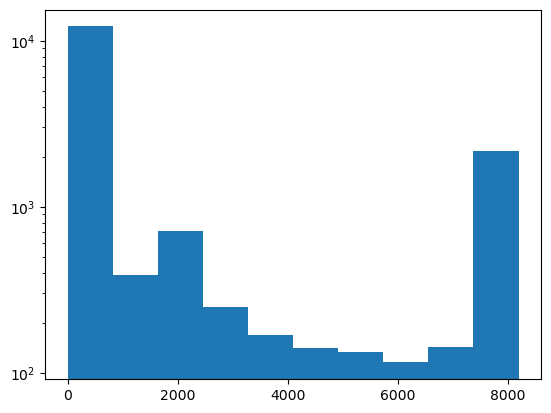

In [33]:
# why use any? why not count how many tokens each neuron is dead for?
runner.model.x_enc.any(dim=0).sum()
plt.hist((runner.model.x_enc == 0).sum(dim=0).cpu().numpy())
plt.yscale('log')

In [13]:
x.shape

torch.Size([1000, 12, 768])

In [16]:
x.norm(dim=-1)

torch.Size([1000, 12])

In [14]:
import numpy as np

np.sqrt(runner_cfg.MODEL.D_MODEL)

27.712812921102035

In [31]:
train_ds

limit=1000000
+- Dataset(
      num_rows=1924184,
      schema={resid_post: numpy.ndarray(shape=(12, 768), dtype=float)}
   )

In [33]:
# def get_scalar(batch):

#     batch['resid_post_norm_sum'] = [np.linalg.norm(batch['resid_post'], ord=2, axis=-1).sum()]
#     # batch['resid_post_norm_count'] = batch['resid_post'].shape[0] * batch['resid_post'].shape[1]
#     batch['resid_post_norm_count'] = [batch['resid_post'].shape[0] * batch['resid_post'].shape[1]]

#     del batch['resid_post']

#     # raise NotImplementedError(batch)

#     return batch

# stats = train_ds.map_batches(get_scalar).sum()

2025-02-14 19:50:52,183	INFO streaming_executor.py:108 -- Starting execution of Dataset. Full logs are in /tmp/ray/session_2025-02-14_18-52-24_879061_2856/logs/ray-data
2025-02-14 19:50:52,183	INFO streaming_executor.py:109 -- Execution plan of Dataset: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadParquet] -> LimitOperator[limit=1000000] -> TaskPoolMapOperator[MapBatches(get_scalar)] -> LimitOperator[limit=1]


Running 0: 0.00 row [00:00, ? row/s]

- ReadParquet->SplitBlocks(2) 1: 0.00 row [00:00, ? row/s]

- limit=1000000 2: 0.00 row [00:00, ? row/s]

- MapBatches(get_scalar) 3: 0.00 row [00:00, ? row/s]

...

- Aggregate 4: 0.00 row [00:00, ? row/s]

Sort Sample 5:   0%|          | 0.00/1.00 [00:00<?, ? row/s]

Shuffle Map 6:   0%|          | 0.00/1.00 [00:00<?, ? row/s]

Shuffle Reduce 7:   0%|          | 0.00/1.00 [00:00<?, ? row/s]

- limit=1 8: 0.00 row [00:00, ? row/s]

140.60230497021485

In [41]:
# scaled_model_dim = np.sqrt(runner_cfg.MODEL.D_MODEL)
# x_mean_l2 = stats['sum(resid_post_norm_sum)'] / stats['sum(resid_post_norm_count)']

# X_SCALAR = np.sqrt(runner_cfg.MODEL.D_MODEL) / x_mean_l2

# scaled_model_dim, x_mean_l2, X_SCALAR

(27.712812921102035, 140.60230497021485, 0.19710070135032787)

In [ ]:
# def get_x_scalar(ds):

#     def get_batch_scalar(batch):

#         return {
#             'resid_post_norm_sum': [np.linalg.norm(batch['resid_post'], ord=2, axis=-1).sum()],
#             'resid_post_norm_count': [batch['resid_post'].shape[0] * batch['resid_post'].shape[1]],
#         }

#     stats = ds.map_batches(get_scalar).sum()


#     scaled_model_dim = np.sqrt(runner_cfg.MODEL.D_MODEL)
#     x_mean_l2 = stats['sum(resid_post_norm_sum)'] / stats['sum(resid_post_norm_count)']

#     X_SCALAR = np.sqrt(runner_cfg.MODEL.D_MODEL) / x_mean_l2

#     return scaled_model_dim, x_mean_l2, X_SCALAR


# scaled_model_dim, x_mean_l2, X_SCALAR = get_x_scalar(train_ds)

In [9]:
scaled_model_dim, x_mean_l2, X_SCALAR = (27.712812921102035, 140.60230497021485, 0.19710070135032787)

In [11]:
def scale_x(batch, X_SCALAR):

    batch['resid_post'] = X_SCALAR * batch['resid_post']

    return batch


train_ds_scaled = train_ds.map_batches(scale_x, X_SCALAR=X_SCALAR, batch_size=CONSTANTS.EXPERIMENT.BATCH_SIZE)

In [ ]:
# from src.scripts import train


# train.main()

In [82]:
import ray, ray.train
from ray.train.torch import TorchTrainer

from scripts.train import train_loop_per_worker



trainer = TorchTrainer(
    ray.tune.with_parameters(train_loop_per_worker, X_SCALAR=0.19710070135032787),
    # train_loop_config=ExperimentConfig(),
    # train_loop_config={
    #     # 'OPTIMIZER': {'parameters': {'lr': }}
    #     'LOSS': {'lambda_s': 0.1}
    # },
    scaling_config=ray.train.ScalingConfig(
        num_workers=CONSTANTS.EXPERIMENT.NUM_TRAINERS,
        use_gpu=True,
        resources_per_worker={'CPU': 1, 'GPU': 1}
    ),
    run_config = ray.train.RunConfig(
        # checkpoint_config=ray.train.CheckpointConfig(num_to_keep=1),
        storage_path='s3://crosscoders/ray/jumprelu'
    ),
    datasets={'train': train_ds}
)
result: ray.train.Result = trainer.fit()


[autoreload of crosscoders.autoencoders.acausal.model failed: Traceback (most recent call last):
  File "/home/ec2-user/crosscoders/.conda/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 276, in check
    superreload(m, reload, self.old_objects)
  File "/home/ec2-user/crosscoders/.conda/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 500, in superreload
    update_generic(old_obj, new_obj)
  File "/home/ec2-user/crosscoders/.conda/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 397, in update_generic
    update(a, b)
  File "/home/ec2-user/crosscoders/.conda/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 349, in update_class
    if update_generic(old_obj, new_obj):
       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/ec2-user/crosscoders/.conda/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 397, in update_generic
    update(a, b)
  File "/home/ec2-user/crosscoders/.conda/lib/pyth

== Status ==
Current time: 2025-02-17 22:11:50 (running for 00:00:00.11)
Using FIFO scheduling algorithm.
Logical resource usage: 2.0/8 CPUs, 1.0/1 GPUs (0.0/1.0 accelerator_type:A10G)
Result logdir: /tmp/ray/session_2025-02-17_18-26-12_887184_15383/artifacts/2025-02-17_22-11-50/TorchTrainer_2025-02-17_22-11-49/driver_artifacts
Number of trials: 1/1 (1 PENDING)


== Status ==
Current time: 2025-02-17 22:11:55 (running for 00:00:05.13)
Using FIFO scheduling algorithm.
Logical resource usage: 2.0/8 CPUs, 1.0/1 GPUs (0.0/1.0 accelerator_type:A10G)
Result logdir: /tmp/ray/session_2025-02-17_18-26-12_887184_15383/artifacts/2025-02-17_22-11-50/TorchTrainer_2025-02-17_22-11-49/driver_artifacts
Number of trials: 1/1 (1 PENDING)


== Status ==
Current time: 2025-02-17 22:12:00 (running for 00:00:10.15)
Using FIFO scheduling algorithm.
Logical resource usage: 2.0/8 CPUs, 1.0/1 GPUs (0.0/1.0 accelerator_type:A10G)
Result logdir: /tmp/ray/session_2025-02-17_18-26-12_887184_15383/artifacts/2025-02-

(TrainTrainable pid=164747) 
(TrainTrainable pid=164747) ------------------------- CONSTANTS -------------------------
(TrainTrainable pid=164747) GlobalsConfig(
(TrainTrainable pid=164747)     PROJECT_ROOT_DIR = '/home/ec2-user/crosscoders',
(TrainTrainable pid=164747)     CONFIG_FILEPATH = '/home/ec2-user/crosscoders/src/scripts/configs/train.yml',
(TrainTrainable pid=164747)     EXPERIMENT = ExperimentConfig(
(TrainTrainable pid=164747)         BATCH_SIZE = 8192,
(TrainTrainable pid=164747)         MAX_RECORDS = None,
(TrainTrainable pid=164747)         MAX_BATCHES = 1000000,
(TrainTrainable pid=164747)         MAX_TOKENS = 1000000,
(TrainTrainable pid=164747)         NUM_GPUS = 1,
(TrainTrainable pid=164747)         NUM_TRAINERS = 1,
(TrainTrainable pid=164747)         HARDWARE = HardwareConfig(
(TrainTrainable pid=164747)             dtype = torch.float32,
(TrainTrainable pid=164747)             device = 'cuda',
(TrainTrainable pid=164747)         ),
(TrainTrainable pid=164747)   

(RayTrainWorker pid=164822) Setting up process group for: env:// [rank=0, world_size=1]
(TorchTrainer pid=164747) Started distributed worker processes: 
(TorchTrainer pid=164747) - (node_id=138a2e87711f44d9d2a85ec6f3b06c040298c536ba28a7a9467feeb8, ip=10.0.1.126, pid=164822) world_rank=0, local_rank=0, node_rank=0


(RayTrainWorker pid=164822) 
(RayTrainWorker pid=164822) 
(RayTrainWorker pid=164822) ------------------------- CONSTANTS -------------------------
(RayTrainWorker pid=164822) GlobalsConfig(
(RayTrainWorker pid=164822)     PROJECT_ROOT_DIR = '/home/ec2-user/crosscoders',
(RayTrainWorker pid=164822)     CONFIG_FILEPATH = '/home/ec2-user/crosscoders/src/scripts/configs/train.yml',
(RayTrainWorker pid=164822)     EXPERIMENT = ExperimentConfig(
(RayTrainWorker pid=164822)         BATCH_SIZE = 8192,
(RayTrainWorker pid=164822)         MAX_RECORDS = None,
(RayTrainWorker pid=164822)         MAX_BATCHES = 1000000,
(RayTrainWorker pid=164822)         MAX_TOKENS = 1000000,
(RayTrainWorker pid=164822)         NUM_GPUS = 1,
(RayTrainWorker pid=164822)         NUM_TRAINERS = 1,
(RayTrainWorker pid=164822)         HARDWARE = HardwareConfig(
(RayTrainWorker pid=164822)             dtype = torch.float32,
(RayTrainWorker pid=164822)             device = 'cuda',
(RayTrainWorker pid=164822)     ), [repe

...

== Status ==
Current time: 2025-02-17 22:12:10 (running for 00:00:20.21)
Using FIFO scheduling algorithm.
Logical resource usage: 2.0/8 CPUs, 1.0/1 GPUs (0.0/1.0 accelerator_type:A10G)
Result logdir: /tmp/ray/session_2025-02-17_18-26-12_887184_15383/artifacts/2025-02-17_22-11-50/TorchTrainer_2025-02-17_22-11-49/driver_artifacts
Number of trials: 1/1 (1 RUNNING)


== Status ==
Current time: 2025-02-17 22:12:15 (running for 00:00:25.24)
Using FIFO scheduling algorithm.
Logical resource usage: 2.0/8 CPUs, 1.0/1 GPUs (0.0/1.0 accelerator_type:A10G)
Result logdir: /tmp/ray/session_2025-02-17_18-26-12_887184_15383/artifacts/2025-02-17_22-11-50/TorchTrainer_2025-02-17_22-11-49/driver_artifacts
Number of trials: 1/1 (1 RUNNING)


== Status ==
Current time: 2025-02-17 22:12:20 (running for 00:00:30.31)
Using FIFO scheduling algorithm.
Logical resource usage: 2.0/8 CPUs, 1.0/1 GPUs (0.0/1.0 accelerator_type:A10G)
Result logdir: /tmp/ray/session_2025-02-17_18-26-12_887184_15383/artifacts/2025-02-

(ReadParquet->SplitBlocks(2) pid=164976) Traceback (most recent call last):
(ReadParquet->SplitBlocks(2) pid=164976)   File "pyarrow/public-api.pxi", line 145, in pyarrow.lib.pyarrow_wrap_data_type
(ReadParquet->SplitBlocks(2) pid=164976)   File "pyarrow/types.pxi", line 606, in pyarrow.lib.LargeListType.init
(ReadParquet->SplitBlocks(2) pid=164976)   File "pyarrow/types.pxi", line 232, in pyarrow.lib.DataType.init
(ReadParquet->SplitBlocks(2) pid=164976)   File "pyarrow/types.pxi", line 105, in pyarrow.lib._datatype_to_pep3118
(ReadParquet->SplitBlocks(2) pid=164976)   File "/home/ec2-user/crosscoders/.conda/lib/python3.12/site-packages/ray/air/util/tensor_extensions/arrow.py", line 461, in __arrow_ext_deserialize__
(ReadParquet->SplitBlocks(2) pid=164976)     @classmethod
(ReadParquet->SplitBlocks(2) pid=164976) 
(ReadParquet->SplitBlocks(2) pid=164976) KeyboardInterrupt: 
(RayTrainWorker pid=164822) Checkpoint successfully created at: Checkpoint(filesystem=s3, path=crosscoders/ray/j

(RayTrainWorker pid=164822) LossMetrics(
(RayTrainWorker pid=164822)     loss = 3587.540771484375,
(RayTrainWorker pid=164822)     error = 2745.27099609375,
(RayTrainWorker pid=164822)     l1 = 84.226318359375,
(RayTrainWorker pid=164822)     lp = 2171.642333984375,
(RayTrainWorker pid=164822)     l0 = 84.23090362548828,
(RayTrainWorker pid=164822)     explained_variance = 0.8262673020362854,
(RayTrainWorker pid=164822)     dead_neurons = DeadNeuronMetrics(
(RayTrainWorker pid=164822)         all_tokens = 0.0023193359375,
(RayTrainWorker pid=164822)         one_token = 0.01678466796875,
(RayTrainWorker pid=164822)         no_token = 0.98321533203125,
(RayTrainWorker pid=164822)     ),
(RayTrainWorker pid=164822) )


2025-02-17 22:16:16,248	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to 'crosscoders/ray/jumprelu/TorchTrainer_2025-02-17_22-11-49' in 0.4144s.
2025-02-17 22:16:16,253	INFO tune.py:1041 -- Total run time: 266.27 seconds (265.50 seconds for the tuning loop).


== Status ==
Current time: 2025-02-17 22:16:16 (running for 00:04:25.91)
Using FIFO scheduling algorithm.
Logical resource usage: 2.0/8 CPUs, 1.0/1 GPUs (0.0/1.0 accelerator_type:A10G)
Result logdir: /tmp/ray/session_2025-02-17_18-26-12_887184_15383/artifacts/2025-02-17_22-11-50/TorchTrainer_2025-02-17_22-11-49/driver_artifacts
Number of trials: 1/1 (1 TERMINATED)




In [83]:
result

(RayTrainWorker pid=164822) [rank0]:[W217 22:16:16.388224656 ProcessGroupNCCL.cpp:1168] Warning: WARNING: process group has NOT been destroyed before we destruct ProcessGroupNCCL. On normal program exit, the application should call destroy_process_group to ensure that any pending NCCL operations have finished in this process. In rare cases this process can exit before this point and block the progress of another member of the process group. This constraint has always been present,  but this warning has only been added since PyTorch 2.4 (function operator())


Result(
  metrics={'loss': 3587.540771484375, 'error': 2745.27099609375, 'l1': 84.226318359375, 'lp': 2171.642333984375, 'l0': 84.23090362548828, 'explained_variance': 0.8262673020362854, 'dead_neurons/all_tokens': 0.0023193359375, 'dead_neurons/one_token': 0.01678466796875, 'dead_neurons/no_token': 0.98321533203125, 'n_tokens': 1000000},
  path='crosscoders/ray/jumprelu/TorchTrainer_2025-02-17_22-11-49/TorchTrainer_2fac6_00000_0_2025-02-17_22-11-50',
  filesystem='s3',
  checkpoint=Checkpoint(filesystem=s3, path=crosscoders/ray/jumprelu/TorchTrainer_2025-02-17_22-11-49/TorchTrainer_2fac6_00000_0_2025-02-17_22-11-50/checkpoint_000000)
)

In [110]:

import os
import boto3
import pathlib


# checkpoint_path = 's3://crosscoders/ray/TorchTrainer_2025-02-14_21-46-50/TorchTrainer_33270_00000_0_2025-02-14_21-46-51/checkpoint_000000'
bucket_name = 'crosscoders'
# checkpoint_s3_key = 'ray/TorchTrainer_2025-02-14_21-46-50/TorchTrainer_33270_00000_0_2025-02-14_21-46-51/checkpoint_000000/model.pt'
# checkpoint_s3_key = 'ray/tune/scaling_tests/best/scaled/TorchTrainer_2025-02-17_19-59-34/TorchTrainer_b6632_00000_0_2025-02-17_19-59-35/checkpoint_000000/model.pt'
checkpoint_s3_key = 'ray/tune/scaling_tests/best/scaled/TorchTrainer_2025-02-17_19-59-34/TorchTrainer_b6632_00000_0_2025-02-17_19-59-35/checkpoint_000000/model.pt'
# checkpoint_s3_key = 'ray/jumprelu/TorchTrainer_2025-02-17_22-11-49/TorchTrainer_2fac6_00000_0_2025-02-17_22-11-50/checkpoint_000000/model.pt'



local = False


# # checkpoint_path = '/home/ec2-user/ray_results/TorchTrainer_2025-02-14_20-01-27/TorchTrainer_79606_00000_0_2025-02-14_20-01-27/checkpoint_000000/model.pt'
# checkpoint_path = '/home/ec2-user/ray_results/TorchTrainer_2025-02-17_18-33-13/TorchTrainer_a569f_00000_0_2025-02-17_18-33-13/checkpoint_000000/model.pt'
# local = True



if not local:
    checkpoint_path = '/tmp/crosscoders/checkpoints/TorchTrainer_2025-02-14_21-46-50/TorchTrainer_33270_00000_0_2025-02-14_21-46-51/checkpoint_000000/model.pt'
    checkpoint_path = pathlib.Path(checkpoint_path)
    os.makedirs(checkpoint_path.parent, exist_ok=True)

    with open(checkpoint_path, 'wb') as infl:
        boto3.resource('s3') \
            .Object(bucket_name, checkpoint_s3_key) \
            .download_fileobj(infl)


with open(checkpoint_path, 'rb') as infl:
    checkpoint_dict = torch.load(infl)

# # delete tmp file if downloaded from s3
# if delete_tmp_file:
#     pathlib.Path(checkpoint_path).unlink()

# checkpoint_dict

/tmp/ipykernel_125816/142734631.py:36: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint_dict = torch.load(infl)


In [112]:
from crosscoders.autoencoders.acausal.model import AcausalAutoencoder

model = AcausalAutoencoder(runner_cfg.MODEL)


# with checkpoint.as_directory() as checkpoint_dir

model.load_state_dict(checkpoint_dict)
model.to(runner_cfg.MODEL.HARDWARE.device)
model.eval()

[autoreload of crosscoders.autoencoders.acausal.model failed: Traceback (most recent call last):
  File "/home/ec2-user/crosscoders/.conda/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 276, in check
    superreload(m, reload, self.old_objects)
  File "/home/ec2-user/crosscoders/.conda/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 500, in superreload
    update_generic(old_obj, new_obj)
  File "/home/ec2-user/crosscoders/.conda/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 397, in update_generic
    update(a, b)
  File "/home/ec2-user/crosscoders/.conda/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 349, in update_class
    if update_generic(old_obj, new_obj):
       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/ec2-user/crosscoders/.conda/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 397, in update_generic
    update(a, b)
  File "/home/ec2-user/crosscoders/.conda/lib/pyth

AcausalAutoencoder()

In [113]:
# t = torch.ones(16384).to('cuda')
# x_enc = torch.rand((10, 16384)).to('cuda')

# # model.W_dec
# ((torch.exp(t) - x_enc) * model.W_dec.norm(dim=-1).sum(-1)).shape

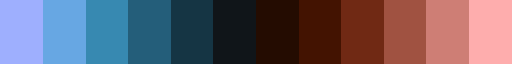

In [114]:
peak_cmap = plt.get_cmap('berlin', runner_cfg.MODEL.N_LAYERS)
peak_cmap

In [115]:
import numpy as np

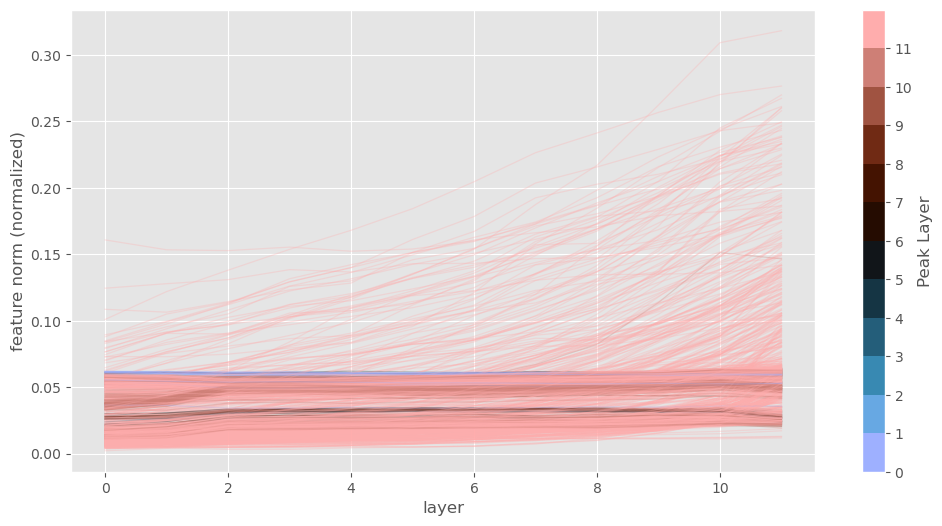

In [116]:
plt.style.use('ggplot')

decoder_norm = model.W_dec.norm(dim=-1)[:1000]
peaks = decoder_norm.max(-1)
peak_layers = peaks.indices.detach().cpu().numpy()
# decoder_norm = decoder_norm / peaks.values.unsqueeze(1)
# decoder_norm = decoder_norm.T
decoder_norm = decoder_norm.detach().cpu().numpy()

# mask = decoder_norm[:,0] < 0.9
mask = np.ones(decoder_norm.shape[0], dtype=bool)

decoder_norm = decoder_norm[mask]
peak_layers = peak_layers[mask]



for i in range(decoder_norm.shape[0]):
    plt.plot(decoder_norm[i], alpha=0.3, linewidth=0.9, color=peak_cmap(peak_layers[i]))




cbar = plt.colorbar(plt.cm.ScalarMappable(cmap=peak_cmap, norm=plt.Normalize(vmin=0, vmax=12)), ax=plt.gca())
cbar.set_label('Peak Layer')
cbar.set_ticks(range(runner_cfg.MODEL.N_LAYERS))

# plt.gca().set_ylim(0.95, 1.01)
plt.gca().set_xlabel('layer')
plt.gca().set_ylabel('feature norm (normalized)')
plt.gcf().set_size_inches(12, 6)

In [108]:
(model.W_dec.norm(dim=-1).max(-1).values < 0.177).sum()

tensor(16381, device='cuda:0')

In [ ]:
x = model.W_dec


x_normalized = x / (x.norm(dim=-1, keepdim=True) + 1e-8)
cosine_similarity = x_normalized @ x_normalized.transpose(-2, -1)
cosine_similarity

IndexError: The shape of the mask [1000] at index 0 does not match the shape of the indexed tensor [16384, 12, 12] at index 0

In [91]:
cossim = cosine_similarity[:10].detach().cpu().numpy()
plt.style.use('default')

Text(0.5, 0, 'layer')

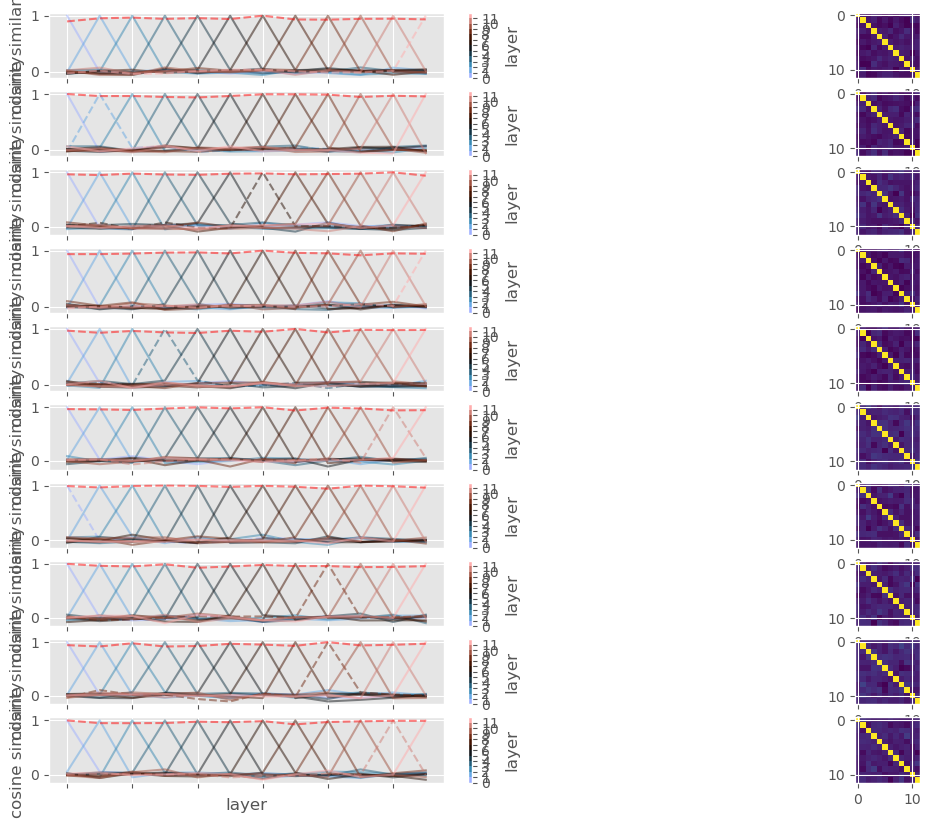

In [95]:
fig, ax = plt.subplots(nrows=len(cossim), ncols=2, figsize=(14, 10))


for i in range(len(ax)):

    for j in range(cossim.shape[1]):
        ax[i][0].plot(cossim[i][j], color=peak_cmap(j), alpha=0.5, linestyle='dashed' if j == peak_colors[i] else 'solid')

    ax[i][0].plot(decoder_norm[i], color='red', alpha=0.5, linestyle='dashed')


    cbar = plt.colorbar(plt.cm.ScalarMappable(cmap=peak_cmap, norm=plt.Normalize(vmin=0, vmax=12)), ax=ax[i][0])
    cbar.set_label('layer')
    cbar.set_ticks(range(runner_cfg.MODEL.N_LAYERS))

    ax[i][0].set_ylabel('cosine similarity')
    ax[i][0].set_xticklabels([])


    ax[i][1].imshow(cossim[i])

    # ax[i][0].set_ylim(-0.15, 0.15)



ax[i][0].set_xlabel('layer')

In [4]:
x = torch.ones((8192, 12, 768), dtype=torch.float64, requires_grad=True)

In [5]:
from crosscoders.autoencoders.acausal.model import JumpReLU


torch.autograd.gradcheck(JumpReLU, x)

AttributeError: 'JumpReLU' object has no attribute 'clone'